# Minimalizace

- Neuvěřitelně široké téma, obzvlášť důležité dnes s nástupem strojového učení.

- V této lekci nebudeme vysvětlovat užitečné minimalizační algoritmy, bude to spíše taková úvodní hra.

- Začneme zábavným příkladem: náhodnou procházkou.

    - Náhodná procházka má pevné místo v historii fyziky, protože Brownův pohyb je náhodná procházka částice v kapalině.

# Náhodná procházka ve 2D

- Podívejte se na následující kód. Poznámky:

    - Volba směru je ve 2D jednoduchá: vygenerujeme náhodné číslo mezi 0 a $2\pi$ a spočítáme kosinus a sinus tohoto úhlu, čímž získáme „jednotkový“ krok.

    - Kód se zastaví, když chodec dosáhne hranice boxu.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def random_direction_2d():
    """ Generates a random direction in the 2D plane """
    phi = np.random.uniform(0, 2 * np.pi)
    return np.array([np.cos(phi), np.sin(phi)])
    

def random_walk(direction_generator, dimension = 2, initial_condition = [0, 0], num_steps = 1000, step_size = 1, box_size = 10, cyclic = True):
    """
    Generates and plots a random walk in a n-D space.

    If the trajectory leaves the given box, the calculation is interrupted.
    The default parameters are set for a 2D random walk.
    To use the function for a different dimension, set the `dimension` parameter and `initial_condition` accordingly.
    The `direction_generator` should be a function that generates a unitary vector
    representing a random direction in the given dimension.
    """    
    position = np.array(initial_condition)
    path = [position]

    box = np.array([box_size] * dimension)

    for _ in range(0, num_steps):
        position = position + step_size * direction_generator()

        # A check whether we leave the given box.
        if (position < -box).any() or (position > box).any():
            if cyclic:
                position = np.mod(position + box, 2 * box) - box
            else:
                break

        path.append(position)

    return np.array(path)

def plot_random_walk_2d(path, box_size = 10):

    plt.plot(path[:,0], path[:,1], label=f"N={len(path)}")
    plt.xlim(-box_size, box_size)
    plt.ylim(-box_size, box_size)
    plt.legend()
    plt.show()

plot_random_walk_2d(random_walk(random_direction_2d, cyclic = False))

- Skript /home/teaching/NOFY084/plesv6am/12_random_walk_2d_interactive.py ([odkaz na umístění v Chimeře](https://hpc.troja.mff.cuni.cz:8000/hub/user-redirect/lab/tree/home/teaching/NOFY084/plesv6am/12_random_walk_2d_interactive.py)) zobrazuje náhodnou procházku v reálném čase. Cyklické okrajové podmínky jsou ve výchozím nastavení `True`.

    - Stáhněte skript a spusťte ho na svém počítači.

# Náhodná procházka ve 3D

- Ve 3D nemůžeme generovat dva sférické úhly, protože bychom dostali nerovnoměrné rozdělení směrů.

- Místo toho můžeme generovat:

    - Úhel $\phi$ z rovnoměrného rozdělení mezi 0 a $2\pi$.

    - Kosinus úhlu $\theta$ z rovnoměrného rozdělení mezi -1 a 1.

    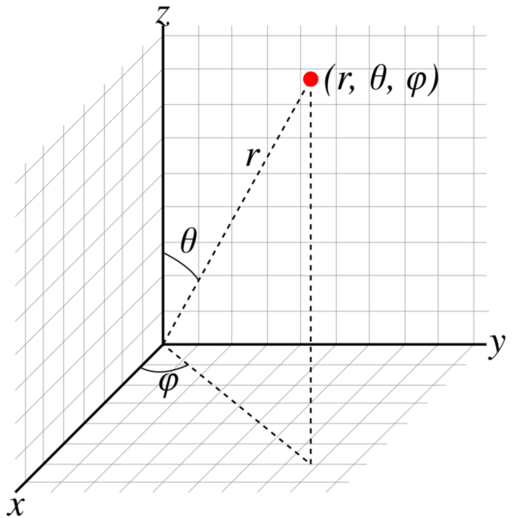

- Označíme-li dvě náhodná čísla $\xi_1$ a $\xi_2$, pak úhly $\phi$ a $\theta$ jsou:

    \begin{align}
        \phi&=\xi_{1},\nonumber\\
        \theta&=\arccos\left(\xi_{2}\right),
    \end{align}

    a jednotkový vektor ve směru je:

    \begin{align}
        \mathbf{e} = (\sin\theta \cos\phi, \sin\theta \sin\phi, \cos\theta)
    \end{align}


In [7]:
# Generate and plot a random walk in 3D.

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def random_direction_3d():
    """ Generates a random direction in the 3D space """
    phi   = np.random.uniform(0, 2 * np.pi)
    theta = np.arccos(np.random.uniform(-1, 1))

    # Return the unitary vector in the direction given by the angles phi and theta.
    return np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

def plot_random_walk_3d(path, box_size = 10):
    """ Plots the given path in 3D. """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(path[:,0], path[:,1], path[:,2], label=f"N={len(path)}")
    ax.set_xlim(-box_size, box_size)
    ax.set_ylim(-box_size, box_size)
    ax.set_zlim(-box_size, box_size)
    ax.legend()
    plt.show()

plot_random_walk_3d(random_walk(random_direction_3d, dimension = 3, initial_condition = [0, 0, 0], cyclic = False))

# Náhodná procházka v n-D

- Generování náhodného směru pomocí goniometrických funkcí je s rostoucí dimenzí čím dál složitější.

- Místo toho můžeme využít fakt, že normální rozdělení s kovarianční maticí rovnou jednotkové matici je v n-D izotropní. Kuchařka:

    - Vygenerujte n náhodných čísel z normálního rozdělení s $\mu = 0$ a $\sigma = 1$.
    
    - Použijte tato čísla jako složky n-D vektoru.
    
    - Vydělte vektor jeho normou.


In [1]:
# Function generating a random direction in n-D space.
def random_direction_gaussian(dimension):
    """
    Generates a random direction in the n-D space.

    References:
    [1] M.E. Muller, A note on a method for generating points uniformly on n-dimensional spheres,
            Communications of the Asociation for Computing Machinery 2, 19 (1959)
    [2] G. Marsaglia, Choosing a Point from the Surface of a Sphere,
            The Annals of Mathematical Statistics 43, 645 (1972)

    Parameters:
    -----------
    dimension : int
        The dimension of the space in which the random direction is generated.
        Any positive integer is allowed.

    Returns:
    --------
    direction : np.ndarray
        A unitary vector representing a random direction in the n-D space.
    """

    # Generate a random vector with normally distributed components.
    random_vector = np.random.normal(size=dimension)

    # Normalize the vector to get a unitary vector.
    norm = np.linalg.norm(random_vector)
    if norm == 0:
        return random_direction(dimension)  # Regenerate if we get a zero vector.
    
    # Return the unitary vector.
    return random_vector / norm

# Minimalizace

- Náhodná procházka je velmi neefektivní způsob, jak najít minimum funkce, ale je to dobrý výchozí bod pro pochopení konceptu minimalizace.

- Kuchařka:

    1. Začněte z náhodného bodu v prostoru.

    2. Zvolte velikost kroku.

    3. Vygenerujte náhodný směr.

    4. Pokud je hodnota funkce v novém bodě menší než v předchozím, přesuňte se do něj.

    5. Vraťte se ke kroku 2 a opakujte, dokud není splněno nějaké kritérium zastavení.

- Kritériem zastavení může být:

    - Tah byl určité množstvíkrát po sobě zamítnut.

    - Hodnota funkce se určité množstvíkrát po sobě nezlepšila. Zde je vhodné nastavit relativní toleranci, která definuje, co znamená „nezlepšila“.

    - Velikost kroku dosáhne nějaké prahové hodnoty.

    - Vymyslete vlastní kritérium.

- Níže uvedený kód minimalizuje funkci pomocí algoritmu náhodné procházky. Velikost kroku může být konstantní nebo adaptivní.

    - U adaptivní velikosti kroku kód zmenší krok faktorem 2 pokaždé, když se mu nepodaří najít lepší pozici po `max_failed_steps` krocích v řadě.
    
    - U neadaptivní velikosti kroku zůstává krok během optimalizace konstantní. Kritérium zastavení je nastaveno na `max_failed_steps = 100` zamítnutých tahů v řadě.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
   
def random_walk_minimizer(function, dimension = 2, initial_step_size = 0.1, final_step_size = 1e-6, initial_condition = None, initial_condition_box = 1, max_failed_steps = 100, adaptive_step_size = True):
    """
    Simple minimization method using random walk.

    Parameters:
    -----------
    function : callable
        The function to minimize.
    dimension : int, optional
        The dimensionality of the function. Default is 2.
    initial_step_size : float, optional
        The initial step size for the random walk. Default is 0.1.
    final_step_size : float, optional
        The final step size for the random walk. Default is 1e-6.
    initial_condition : array-like, optional
        The starting point; if None, initial conditions chosen randomly from a box of size given by initial_condition_box.
    initial_condition_box : float, optional
        The size of the box from which to choose the initial condition. Default is 1.
    max_failed_steps : int, optional
        The number of steps to stop the calculation. Default is 100.
    adaptive_step_size : bool, optional
        Whether to adapt the step size during the optimization.
        If True, the step size is reduced by a factor of 2 every time we fail
        to find a better position for `max_failed_steps` consecutive steps.
        If False, the step size remains constant throughout the optimization,
        and the stopping criterion is simply `failed_steps == max_failed_steps`.
    """

    # Set the starting position.
    if initial_condition is None:
        initial_condition = np.random.uniform(-initial_condition_box, initial_condition_box, size = dimension)
    position = np.array(initial_condition)
    f = function(position)
    path = [position]

    # Number of consecutive steps in which we haven't moved.
    failed_steps = 0

    # Initial step size.
    step_size = initial_step_size

    # Total number of steps.
    num_steps = 0

    # The random walk.
    while ((adaptive_step_size) and (step_size > final_step_size)) or ((not adaptive_step_size) and (failed_steps < max_failed_steps)):
        new_position = position + step_size * random_direction_gaussian(dimension)
        newf = function(new_position)

        if newf < f:
            position = new_position
            f = newf

            path.append(position)

            failed_steps = 0

        else:
            failed_steps += 1           # Rejected step

            if adaptive_step_size and failed_steps > max_failed_steps:
                failed_steps = 0
                step_size *= 0.5        # Step size reduced by half 

        num_steps += 1

    print(f"Minimum = {position}, function value = {f}, steps = {num_steps}")

    return np.array(path)


- Minimalizujte funkci $f(x, y) = x^2 + y^2$


In [12]:
# Define the function to minimize.
def f(x):
    return x[0]**2 + x[1]**2

# Run the minimization.
# Check the number of steps and the minimum found by the algorithm.
# You can see that the non-adaptive step size takes less steps,
# but it doesn't find the minimum as accurately as the adaptive step size.
_ = random_walk_minimizer(f, adaptive_step_size = False)

- Vykresleme cestu, kterou algoritmus prošel, do vrstevnicového grafu funkce. Je vidět, že neadaptivní velikost kroku potřebuje méně kroků, ale minimum nenajde tak přesně jako adaptivní velikost kroku.


In [2]:
# Colour maps for the contour graph
from matplotlib import cm

def show_graph(function, paths = (), box_size = 1, num_contours = 100):
    """
    Plots a contour graphs of the give 2D function.

    Parameters:
    -----------
    function : callable
        The function to plot.
    paths : tuple, optional
        The paths to plot in the graph.
        There can be any number of paths plotted in the same graph.
    box_size : float, optional
        The limits of the x, y range.
    num_contours : int, optional
        The number of contours in the graph.
    """

    # Range of x and y values for the graph.
    x = y = np.linspace(-box_size, box_size, 100)

    # Grid for calculating values of the function on the graph.
    grid_x, grid_y = np.meshgrid(x, y)
    grid_z = function([grid_x, grid_y])

    plt.figure(figsize=(8,6))
    plt.contourf(grid_x, grid_y, grid_z, num_contours, cmap = cm.hot)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(label = function.__name__ + '(x,y)')

    for path in paths:
        plt.plot(path[:,0], path[:,1])  
        plt.scatter(path[[0,-1],0], path[[0,-1],1])  # Indicate the initial and final points of the path
    plt.tight_layout()
    plt.show()


In [15]:
path = random_walk_minimizer(f, adaptive_step_size = False, initial_condition_box = 2)
show_graph(f, paths = (path,))

- Najděte minimum Rosenbrockovy funkce:

    \begin{align}
        f(x, y) = (a - x)^2 + b(y - x^2)^2
    \end{align}

    kde $a = 1$ a $b = 100$.


In [3]:
def rosenbrock(point, parameters = (1, 100)):
    """
    Rosenbrock test function: https://en.wikipedia.org/wiki/Rosenbrock_function
    """
    x, y = point
    a, b = parameters

    return (a - x)**2 + b * (y - x * x)**2

paths = []
for _ in range(5):
    path = random_walk_minimizer(rosenbrock, adaptive_step_size = True, initial_condition_box = 3)
    paths.append(path)
show_graph(rosenbrock, paths = paths, box_size = 3, num_contours = 30)

NameError: name 'random_walk_minimizer' is not defined

In [38]:
import numpy as np

def f2min(x):
    return x ** 4 - 2 * x ** 2 + x

def random_walk_minimizer2(function, dimension = 2, initial_step_size = 0.1, final_step_size = 1e-6, initial_condition = None, initial_condition_box = 1, max_failed_steps = 100, adaptive_step_size = True):
    """
    Simple minimization method using random walk.

    Parameters:
    -----------
    function : callable
        The function to minimize.
    dimension : int, optional
        The dimensionality of the function. Default is 2.
    initial_step_size : float, optional
        The initial step size for the random walk. Default is 0.1.
    final_step_size : float, optional
        The final step size for the random walk. Default is 1e-6.
    initial_condition : array-like, optional
        The starting point; if None, initial conditions chosen randomly from a box of size given by initial_condition_box.
    initial_condition_box : float, optional
        The size of the box from which to choose the initial condition. Default is 1.
    max_failed_steps : int, optional
        The number of steps to stop the calculation. Default is 100.
    adaptive_step_size : bool, optional
        Whether to adapt the step size during the optimization.
        If True, the step size is reduced by a factor of 2 every time we fail
        to find a better position for `max_failed_steps` consecutive steps.
        If False, the step size remains constant throughout the optimization,
        and the stopping criterion is simply `failed_steps == max_failed_steps`.
    """

    # Set the starting position.
    if initial_condition is None:
        initial_condition = np.random.uniform(-initial_condition_box, initial_condition_box, size = dimension)
    position = np.array(initial_condition)
    f = function(position)
    path = [position]

    # Number of consecutive steps in which we haven't moved.
    failed_steps = 0

    # Initial step size.
    step_size = initial_step_size

    # Total number of steps.
    num_steps = 0

    # The random walk.
    while ((adaptive_step_size) and (step_size > final_step_size)) or ((not adaptive_step_size) and (failed_steps < max_failed_steps)):
        new_position = position + step_size * random_direction_gaussian(dimension)
        newf = function(new_position)
        probability = np.random.uniform(0, 1)

        if newf < f or probability < 0.05:
            position = new_position
            f = newf

            path.append(position)

            failed_steps = 0

        else:
            failed_steps += 1           # Rejected step

            if adaptive_step_size and failed_steps > max_failed_steps:
                failed_steps = 0
                step_size *= 0.5        # Step size reduced by half 

        num_steps += 1

    print(f"Minimum = {position}, function value = {f}, steps = {num_steps}")

    return np.array(path)

In [ ]:
_ = random_walk_minimizer2(f2min, dimension = 1, initial_condition=)

Minimum = [0.83756568], function value = [-0.07334178], steps = 84452
